In [ ]:
 pip install pyspark

In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import psutil
import pyspark
import pandas as pd
import numpy as np
import re
from collections import Counter
import csv

print("CPU usage percentage:", psutil.cpu_percent())

CPU usage percentage: 9.4


In [2]:
spark = SparkSession.builder \
    .appName("Bali Popular Destination for Tourist 2022 Analysis") \
    .getOrCreate()
print(psutil.cpu_percent())

print("CPU usage percentage:", psutil.cpu_percent())

17.7
CPU usage percentage: 0.0


In [3]:
df = spark.read.csv('C:/Users/ameli/Documents/Semester 4/PEMPAR/tubes pempar/tubes pempar/Bali Popular Destination for Tourist 2022 - Sheet1.csv', header=True, inferSchema=True)
df.show(df.count(), truncate=False)

print("CPU usage percentage:", psutil.cpu_percent())

+----------------------------------+----------------------------------------------------------------------------------------------------------------------------------+---------------------------------+---------------------+----------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import psutil

# Path ke file CSV
file_path = 'C:/Users/ameli/Documents/Semester 4/PEMPAR/tubes pempar/tubes pempar/Bali Popular Destination for Tourist.csv'

# Membaca file CSV
bali_data = pd.read_csv(file_path)

# Mengambil kolom 'Place' dan 'Google Reviews (Count)'
places = bali_data['Place']
reviews = bali_data['Google Reviews (Count)']

# Membuat plot
plt.figure(figsize=(12, 8))
bars = plt.bar(places, reviews, color='blue')

# Menghitung total jumlah ulasan
total_reviews = reviews.sum()

# Menambahkan teks jumlah ulasan dan persentase pada setiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval}\n({yval / total_reviews:.2%})', ha='center', va='bottom', fontsize=8)

# Menambahkan label dan judul pada plot
plt.xlabel('Place')
plt.ylabel('Jumlah Ulasan Google')
plt.title('Destinasi Wisata Populer di Bali (2022)')
plt.xticks(rotation=90)
plt.tight_layout()

# Menampilkan plot
plt.show()

# Mengukur persentase penggunaan CPU
print("CPU usage percentage:", psutil.cpu_percent())


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/ameli/Documents/Semester 4/PEMPAR/tubes pempar/tubes pempar/Bali Popular Destination for Tourist.csv'

In [ ]:
df.select("Place", "Location").show(df.count(), truncate=False)

print("CPU usage percentage:", psutil.cpu_percent())

+----------------------------------+----------------------------------------------------------------------------------------------------------------------------------+
|Place                             |Location                                                                                                                          |
+----------------------------------+----------------------------------------------------------------------------------------------------------------------------------+
|Tanah Lot                         |Beraban, Kec. Kediri, Kabupaten Tabanan, Bali 82121                                                                               |
|Mount Batur                       |Bangli Regency, Bali, Indonesia                                                                                                   |
|Uluwatu Temple                    |Uluwatu (South Kuta, Badung)                                                                                                

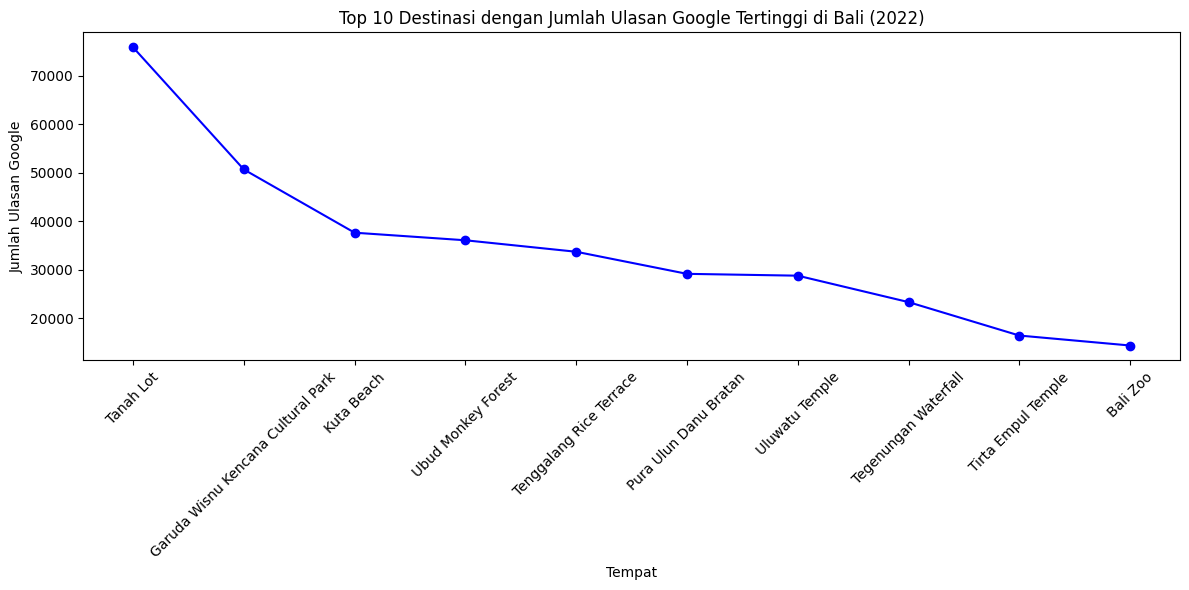

Persentase penggunaan CPU: 100.0


In [ ]:
spark = SparkSession.builder.appName("BaliDestinations").getOrCreate()

# Query SQL untuk memilih 10 destinasi dengan jumlah ulasan Google tertinggi
top_destinations_query = """
SELECT
    Place,
    `Google Reviews (Count)`
FROM
    bali_destinations
ORDER BY
    `Google Reviews (Count)` DESC
LIMIT 10
"""

# Menjalankan query SQL
top_destinations = spark.sql(top_destinations_query)

# Mengonversi hasil query ke Pandas DataFrame untuk plotting
top_destinations_df = top_destinations.toPandas()

# Plotting menggunakan Pandas DataFrame
plt.figure(figsize=(12, 6))
plt.plot(top_destinations_df['Place'], top_destinations_df['Google Reviews (Count)'], marker='o', color='b', linestyle='-')

# Menambahkan label dan judul
plt.xlabel('Tempat')
plt.ylabel('Jumlah Ulasan Google')
plt.title('Top 10 Destinasi dengan Jumlah Ulasan Google Tertinggi di Bali (2022)')
plt.xticks(rotation=45)
plt.tight_layout()

# Menampilkan plot
plt.show()

# Mengukur penggunaan CPU setelah menjalankan query
print("Persentase penggunaan CPU:", psutil.cpu_percent())

In [ ]:
# Inisialisasi SparkSession
spark = SparkSession.builder.appName("BaliDestinations").getOrCreate()

# Query SQL untuk menghitung rata-rata dan maksimum rating berdasarkan kategori
rating_stats_query = """
SELECT Location, AVG(`Google Maps Rating`) AS Avg_Rating, MAX(`Google Maps Rating`) AS Max_Rating
FROM bali_destinations
GROUP BY Location
ORDER BY Avg_Rating DESC
"""

# Menjalankan query SQL
rating_stats = spark.sql(rating_stats_query)

# Menampilkan hasil
rating_stats.show(truncate=False)

# Inisialisasi SparkSession
spark = SparkSession.builder.appName("BaliDestinations").getOrCreate()

# Path file CSV
file_path = 'Bali Popular Destination for Tourist 2022.csv'

# Baca data dari file CSV ke DataFrame Spark
df_bali = spark.read.csv(file_path, header=True, inferSchema=True)

# Membuat tampilan sementara dari DataFrame untuk digunakan dalam SQL
df_bali.createOrReplaceTempView("bali_destinations")

# Check the available columns
print(df_bali.columns)

# Mengukur penggunaan CPU setelah menjalankan query (opsional)
print("CPU usage percentage:", psutil.cpu_percent())

+----------------------------------------------------------------------------------------------------------------------------------+----------+----------+
|Location                                                                                                                          |Avg_Rating|Max_Rating|
+----------------------------------------------------------------------------------------------------------------------------------+----------+----------+
|Jl. Penglipuran, Kubu, Kec. Bangli, Kabupaten Bangli, Bali 80611                                                                  |4.8       |4.8       |
|CFX9+9GG, Jl. Raya Goa Lawah, Pesinggahan, Kec. Dawan, Kabupaten Klungkung, Bali 80761                                            |4.7       |4.7       |
|Danau Beratan, Candikuning, Kec. Baturiti, Kabupaten Tabanan, Bali 82191                                                          |4.7       |4.7       |
|Jl. Kartika Plaza, Tuban, Kec. Kuta, Kabupaten Badung, Bali 80361    

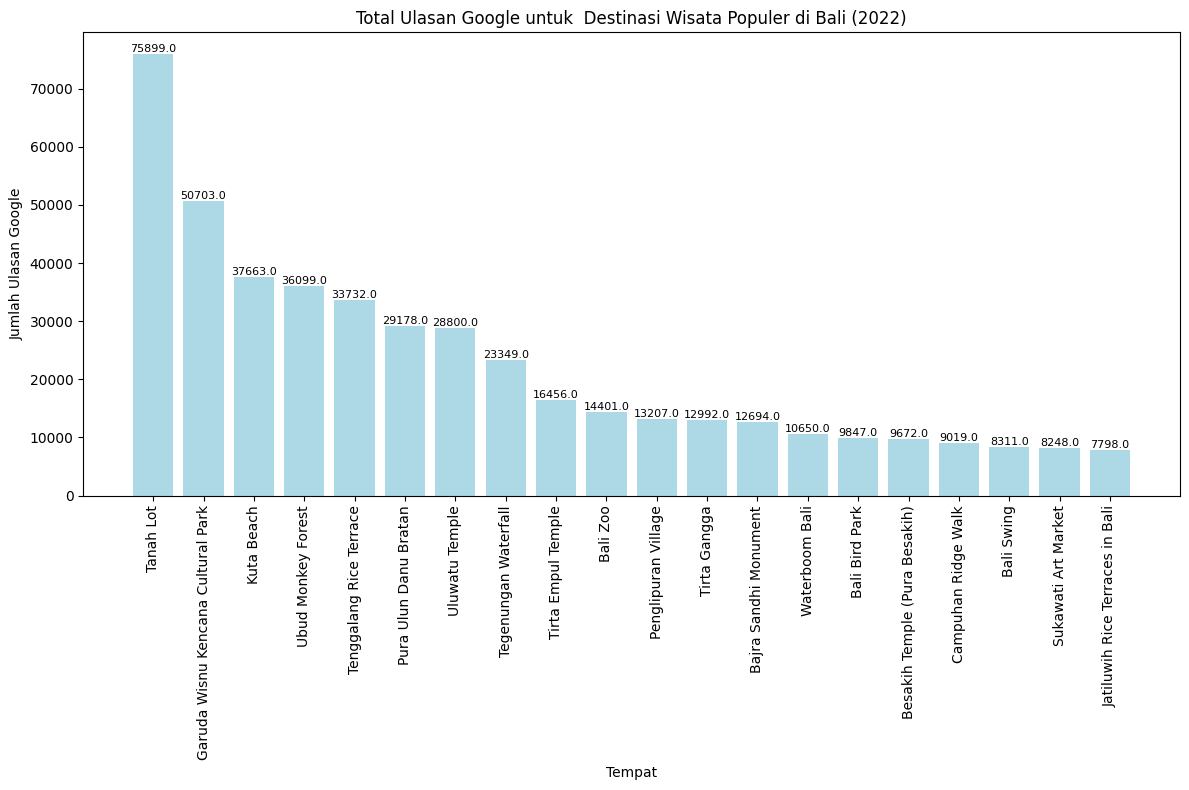

Persentase penggunaan CPU: 29.9


In [ ]:
# Inisialisasi SparkSession
spark = SparkSession.builder.appName("BaliDestinations").getOrCreate()

# Query SQL untuk mengambil data ulasan destinasi wisata di Bali
review_query = """
SELECT Place, `Google Reviews (Count)`
FROM bali_destinations
ORDER BY `Google Reviews (Count)` DESC
LIMIT 20
"""

# Menjalankan query dan menyimpan hasilnya di review_data
review_data = spark.sql(review_query)

# Mengonversi hasil query ke Pandas DataFrame untuk plotting
places = review_data.toPandas()['Place']
reviews = review_data.toPandas()['Google Reviews (Count)']

# Membuat plot diagram batang
plt.figure(figsize=(12, 8))
bars = plt.bar(places, reviews, color='lightblue')

# Menambahkan label di atas setiap batang dengan ukuran font yang lebih kecil
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height}', ha='center', va='bottom', fontsize=8)

# Menambahkan label dan judul
plt.xlabel('Tempat')
plt.ylabel('Jumlah Ulasan Google')
plt.title('Total Ulasan Google untuk  Destinasi Wisata Populer di Bali (2022)')
plt.xticks(rotation=90)
plt.tight_layout()

# Menampilkan plot
plt.show()

# Mengukur penggunaan CPU
print("Persentase penggunaan CPU:", psutil.cpu_percent())

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lower, explode, split, desc

# Inisialisasi SparkSession
spark = SparkSession.builder.appName("WordCount").getOrCreate()

# Membaca data dari CSV ke DataFrame Spark
file_path = 'Bali Popular Destination for Tourist 2022.csv'
df_bali = spark.read.csv(file_path, header=True, inferSchema=True)

# Memproses kolom 'Place' untuk word count
# Mengubah teks menjadi huruf kecil dan memecah kata-kata
word_counts = df_bali.withColumn('Place', lower(col('Place'))) \
                     .withColumn('Words', split(col('Place'), ' ')) \
                     .select(explode('Words').alias('Word')) \
                     .groupBy('Word').count() \
                     .orderBy(desc('count'))

# Menampilkan 10 baris teratas dari hasil word count
print("Top 10 Kata Sering Muncul:")
word_counts.show(10)

# Menyimpan hasil 10 kata teratas yang paling sering muncul ke file CSV
word_counts.coalesce(1).write.format("com.databricks.spark.csv") \
                          .option("header", "true") \
                          .mode("overwrite") \
                          .save("top_10_word_counts.csv")

print("Persentase penggunaan CPU:", psutil.cpu_percent())

Top 10 Kata Sering Muncul:
+-------+-----+
|   Word|count|
+-------+-----+
|   bali|    8|
|   park|    4|
| temple|    4|
|  beach|    3|
|   pura|    2|
|    goa|    2|
|   rice|    2|
|village|    2|
|  tirta|    2|
|    art|    1|
+-------+-----+
only showing top 10 rows

Persentase penggunaan CPU: 19.0


In [ ]:
spark.stop()